# HI

In [65]:
!pip install kagglehub
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install jinja2


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
  Obtaining dependency information for jinja2 from https://files.pythonhosted.org/packages/62/a1/3d680cbfd5f4b8f15abc1d571870c5fc3e594bb582bc3b64ea099db13e56/jinja2-3.1.6-py3-none-any.whl.metadata
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Obtaining dependency information for MarkupSafe>=2.0 from ht

In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Check what files were downloaded
print("Files in dataset folder:", os.listdir(path))

# Download latest version
path = kagglehub.dataset_download("nikhil1e9/loan-default")
file_path = os.path.join(path, 'Loan_default.csv')

df = pd.read_csv(file_path)
df.head()

Files in dataset folder: ['Loan_default.csv']


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [49]:
default_counts = df['Default'].value_counts(normalize=True) * 100
print(f"Non-Default (0): {default_counts[0]:.2f}%")
print(f"Default (1):     {default_counts[1]:.2f}%")

Non-Default (0): 88.39%
Default (1):     11.61%


In [53]:
# Total count of missing values per column
missing_count = df.isnull().sum()
display(missing_count)

# Percentage of missing values per column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into a single summary table
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percentage.round(2)
})

# Display columns that have missing values (or all if none are missing)
if df.isnull().sum().sum() == 0:
    print("✅ No missing values found in any column!")
else:
    # Show only the columns that actually have missing data
    display(missing_df[missing_df['Missing Count'] > 0])

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

✅ No missing values found in any column!


In [66]:
# Create a copy to preserve the original dataframe
df_encoded = df.copy()

# 1. Binary Mapping (Yes/No -> 1/0)
binary_cols = ['HasMortgage', 'HasDependents', 'HasCoSigner']
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0})

# 2. Ordinal Encoding for Education (inherent order)
education_map = {
    'High School': 0,
    'Bachelor\'s': 1,
    'Master\'s': 2,
    'PhD': 3
}
df_encoded['Education'] = df_encoded['Education'].map(education_map)

# 3. One-Hot Encoding for Nominal Categories (no implicit order)
df_encoded = pd.get_dummies(
    df_encoded,
    columns=['EmploymentType', 'MaritalStatus', 'LoanPurpose'],
    drop_first=True,  # Avoids multicollinearity (dummy variable trap)
    dtype=int
)

# 4. Drop non-predictive identifier colum

if 'LoanID' in df_encoded.columns:
    df_encoded.drop(columns=['LoanID'], inplace=True)

df_encoded.head(10)

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,...,Default,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,56,85994,50587,520,80,4,15.23,36,0.44,1,...,0,0,0,0,0,0,0,0,0,1
1,69,50432,124440,458,15,1,4.81,60,0.68,2,...,0,0,0,0,1,0,0,0,0,1
2,46,84208,129188,451,26,3,21.17,24,0.31,2,...,1,0,0,1,0,0,0,0,0,0
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,0,0,0,0,1,0,1,0,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,1,...,0,0,0,1,0,0,0,0,0,0
5,25,90298,90448,720,18,2,22.72,24,0.10,0,...,1,0,0,1,0,1,1,0,0,0
6,38,111188,177025,429,80,1,19.11,12,0.16,1,...,0,0,0,1,0,1,0,0,1,0
7,56,126802,155511,531,67,4,8.15,60,0.43,3,...,0,0,0,0,1,0,0,0,1,0
8,36,42053,92357,827,83,1,23.94,48,0.20,1,...,1,0,1,0,0,0,0,1,0,0
9,40,132784,228510,480,114,4,9.09,48,0.33,0,...,0,0,1,0,1,0,0,0,0,1


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,HasMortgage,HasDependents,HasCoSigner,Default,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
Age,1.00000,-0.00124,-0.00221,-0.00055,-0.00034,-0.00089,-0.00113,0.00026,-0.00469,-0.00085,0.00003,0.00071,-0.00292,-0.16778,-0.00266,-0.00008,0.00162,0.00189,-0.00284,-0.00310,-0.00230,-0.00047,0.00429
Income,-0.00124,1.00000,-0.00087,-0.00143,0.00267,-0.00202,-0.00230,-0.00100,0.00021,0.00068,-0.00094,-0.00157,-0.00352,-0.09912,-0.00163,-0.00078,-0.00336,-0.00082,0.00096,0.00512,-0.00361,-0.00125,-0.00039
LoanAmount,-0.00221,-0.00087,1.00000,0.00126,0.00282,0.00079,-0.00229,0.00254,0.00112,0.00254,-0.00080,0.00014,-0.00185,0.08666,-0.00204,-0.00116,0.00408,-0.00328,0.00097,-0.00309,0.00047,0.00031,0.00036
CreditScore,-0.00055,-0.00143,0.00126,1.00000,0.00061,0.00002,0.00044,0.00113,-0.00104,-0.00080,0.00173,-0.00302,-0.00275,-0.03417,-0.00062,0.00151,0.00221,0.00011,-0.00284,-0.00064,-0.00331,0.00251,0.00045
MonthsEmployed,-0.00034,0.00267,0.00282,0.00061,1.00000,0.00127,0.00010,-0.00117,0.00176,-0.00115,0.00021,0.00145,0.00105,-0.09737,0.00136,0.00068,-0.00042,0.00106,-0.00061,0.00152,0.00116,-0.00403,-0.00021
NumCreditLines,-0.00089,-0.00202,0.00079,0.00002,0.00127,1.00000,-0.00030,-0.00023,-0.00059,0.00153,-0.00174,-0.00190,0.00211,0.02833,0.00017,0.00075,-0.00037,0.00073,-0.00094,0.00099,0.00204,0.00037,-0.00124
InterestRate,-0.00113,-0.00230,-0.00229,0.00044,0.00010,-0.00030,1.00000,0.00089,0.00058,0.00342,-0.00042,-0.00024,-0.00399,0.13127,0.00028,-0.00102,0.00104,-0.00147,-0.00366,-0.00103,0.00149,0.00258,-0.00113
LoanTerm,0.00026,-0.00100,0.00254,0.00113,-0.00117,-0.00023,0.00089,1.00000,0.00227,-0.00142,0.00178,0.00242,-0.00117,0.00054,0.00051,-0.00275,0.00233,-0.00009,-0.00085,-0.00303,0.00094,-0.00032,0.00305
DTIRatio,-0.00469,0.00021,0.00112,-0.00104,0.00176,-0.00059,0.00058,0.00227,1.00000,0.00195,0.00023,0.00149,0.00037,0.01924,0.00089,-0.00034,-0.00057,-0.00037,0.00407,0.00048,0.00251,-0.00167,-0.00350
Education,-0.00085,0.00068,0.00254,-0.00080,-0.00115,0.00153,0.00342,-0.00142,0.00195,1.00000,0.00196,0.00006,0.00169,-0.02828,0.00083,0.00014,-0.00007,0.00017,-0.00142,-0.00019,-0.00035,-0.00002,-0.00156


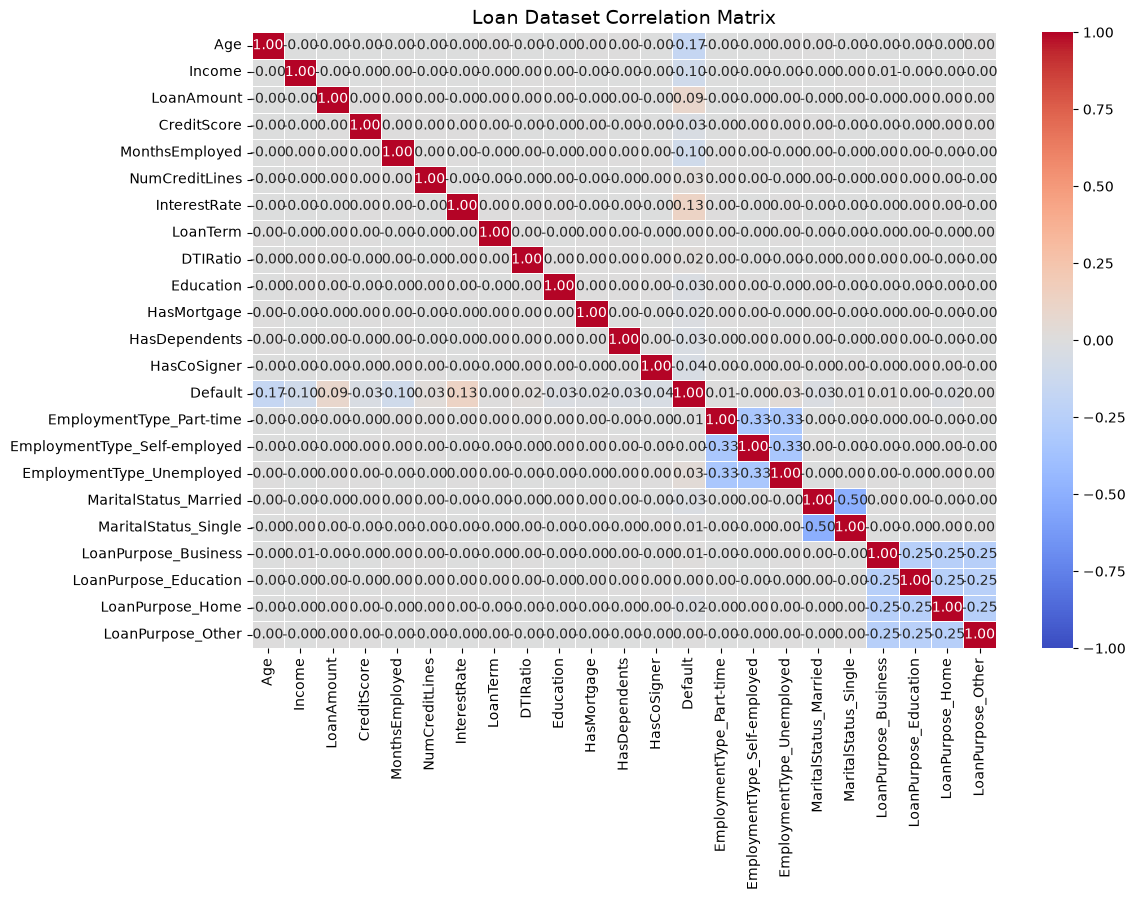

In [76]:
corr_matrix = df_encoded.corr()

# 2. Display the matrix as a styled DataFrame (color-coded numbers)
display(corr_matrix.style.background_gradient(cmap='coolwarm', axis=None).format("{:.5f}"))

# 3. Plot a clean visual heatmap of the matrix
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # Show values in cells
    fmt=".2f",           # Round values to 2 decimal places
    cmap='coolwarm',     # Red = Positive correlation, Blue = Negative correlation
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Loan Dataset Correlation Matrix", fontsize=14)
plt.show()

In [77]:
# Extract target correlation and sort by absolute strength
target_corr = df_encoded.corr()['Default'].drop('Default')
target_corr_abs = target_corr.abs().sort_values(ascending=False)

# Display top correlated features
top_features_summary = pd.DataFrame({
    'Correlation': target_corr[target_corr_abs.index],
    'Absolute Correlation': target_corr_abs
})

print("Top features related to Loan Default:")
display(top_features_summary)

Top features related to Loan Default:


,Correlation,Absolute Correlation
Age,-0.167783,0.167783
InterestRate,0.131273,0.131273
Income,-0.099119,0.099119
MonthsEmployed,-0.097374,0.097374
LoanAmount,0.086659,0.086659
HasCoSigner,-0.039109,0.039109
EmploymentType_Unemployed,0.034957,0.034957
HasDependents,-0.034678,0.034678
CreditScore,-0.034166,0.034166
NumCreditLines,0.028330,0.028330
